# 07. Komuter data check (Version 6, step 1)

Is the KTM Komuter hourly origin-destination data fit to build Version 6 on? This notebook loads every year, removes the pseudo-stations, keeps every trip with **at least one end in the Klang Valley**, looks into the falling trend, and saves a clean file for the next notebooks.

| Section | What it does |
|---|---|
| 0 | Settings |
| 1 | Load each year (downloaded once, then cached) |
| 2 | Clean: pseudo-stations and the ramp-up month |
| 3 | Station list: region and corridor of each station |
| 4 | Keep trips with at least one Klang Valley end |
| 5 | The falling trend: everywhere, or in particular places? |
| 6 | A first look at the hours |
| 7 | Save the outputs |

**Data:** Hourly Origin-Destination Ridership: Komuter (data.gov.my, CC BY 4.0). Each row is one origin, one destination, one date and one hour; `09:00` covers 09:00 to 09:59.

**Provisional station regions:** Section 3 uses a typed list of stations by district. Step 2 of Version 6 will check it against the KTMB GTFS station coordinates.

Needs `data/raw/komuter_2023.parquet` to `komuter_2026.parquet` (downloaded by hand if the download in Section 1 is blocked).

## 0. Settings

In [1]:
from pathlib import Path
import json
from datetime import datetime
import requests
import pandas as pd
import matplotlib.pyplot as plt

FIRST_YEAR = 2023                 # <- earliest year to load (the data starts on 10 September 2023)
REFRESH_CURRENT_YEAR = False      # <- True = re-download the current year's file, which grows every day

START_DATE = "2023-10-01"         # <- first date kept; September 2023 is a ramp-up month (about 5,000 trips a day)
DROP_STATIONS = ["Unknown", "Penalty"]   # <- pseudo-stations, not places

# Same season as the main map, and an earlier year to compare with
SEASON = ("06-01", "08-31")       # <- (start, end) as month-day
COMPARE_FROM = 2024               # <- earlier year (2023 has no June to August data)
COMPARE_TO = 2026                 # <- later year
MIN_DAILY = 100                   # <- stations with fewer entries a day are left out of the change table

# Hour windows for the morning and evening peaks (start hour, end hour, inclusive)
AM_PEAK = (6, 9)                  # <- 06:00 to 09:59
PM_PEAK = (16, 19)                # <- 16:00 to 19:59

PROCESSED = Path("data/processed")
RAW = Path("data/raw")
PROCESSED.mkdir(parents=True, exist_ok=True)
RAW.mkdir(parents=True, exist_ok=True)
OD_URL = "https://storage.data.gov.my/transportation/ktmb/komuter_{year}.parquet"
this_year = datetime.now().year
YEARS = list(range(FIRST_YEAR, this_year + 1))
print("Years to load:", YEARS)

Years to load: [2023, 2024, 2025, 2026]


## 1. Load each year

Files are read from `data/raw` if they are there; otherwise they are downloaded. The four years together are about 6.8 million rows.

In [2]:
def get_year(year):
    path = RAW / f"komuter_{year}.parquet"
    if not path.exists() or (REFRESH_CURRENT_YEAR and year == this_year):
        url = OD_URL.format(year=year)
        print(f"Downloading {url}")
        r = requests.get(url, timeout=600)
        r.raise_for_status()
        path.write_bytes(r.content)
    else:
        print(f"Using cached {path}")
    return pd.read_parquet(path)

od = pd.concat([get_year(y) for y in YEARS], ignore_index=True)
od["date"] = pd.to_datetime(od["date"])
od["hour"] = od["time"].str[:2].astype(int)
print(f"\n{len(od):,} rows, {od['ridership'].sum():,} trips, "
      f"{od['date'].min().date()} to {od['date'].max().date()}")

Using cached data\raw\komuter_2023.parquet
Using cached data\raw\komuter_2024.parquet
Using cached data\raw\komuter_2025.parquet
Using cached data\raw\komuter_2026.parquet

6,835,798 rows, 31,843,826 trips, 2023-09-10 to 2026-09-30


## 2. Clean: pseudo-stations and the ramp-up month

`Unknown` and `Penalty` are ticketing records, not stations. Trips with either end at one of them are removed. Dates before `START_DATE` are also removed.

In [3]:
total = od["ridership"].sum()
pseudo = od["origin"].isin(DROP_STATIONS) | od["destination"].isin(DROP_STATIONS)
early = od["date"] < START_DATE
print(f"Pseudo-station trips removed: {od.loc[pseudo, 'ridership'].sum():,} ({od.loc[pseudo, 'ridership'].sum() / total:.2%})")
print(f"Trips before {START_DATE} removed: {od.loc[early & ~pseudo, 'ridership'].sum():,}")
od = od[~pseudo & ~early].copy()

# Every day present?
days = pd.date_range(od["date"].min(), od["date"].max())
missing = days.difference(od["date"].unique())
print(f"\n{len(days):,} days from {days[0].date()} to {days[-1].date()}; missing days: {len(missing)}")
if len(missing):
    print(list(missing.date))

Pseudo-station trips removed: 105,938 (0.33%)
Trips before 2023-10-01 removed: 107,769

1,096 days from 2023-10-01 to 2026-09-30; missing days: 0


## 3. Station list: region and corridor of each station

Each station is given a **region** and a **corridor** (provisional, by name; Step 2 checks it with coordinates):

- **Klang Valley:** KL, Putrajaya, and the Selangor districts Petaling, Gombak, Ulu Langat, Klang and Sepang (the same scope as the main map).
- **Outer belt:** Hulu Selangor, Tanjong Malim and Negeri Sembilan, where many people commute into the Klang Valley.
- **Other:** stations further away (Perak beyond Tanjong Malim, Johor).

Corridors: the **Seremban Line** (Batu Caves to Pulau Sebang) and the **Port Klang Line** (Tanjung Malim to Pelabuhan Klang) share the central section from Putra to KL Sentral, marked **Shared core**.

Any station not in the list is printed below, so it can be added.

In [4]:
KV = "Klang Valley"; OUTER = "Outer belt"; OTHER = "Other"
SER = "Seremban Line"; PKL = "Port Klang Line"; CORE = "Shared core"; OTH = "Other"

STATIONS = {   # name: (region, district, corridor)
    # Shared core (KL)
    "Putra": (KV, "Kuala Lumpur", CORE), "Bank Negara": (KV, "Kuala Lumpur", CORE),
    "Kuala Lumpur": (KV, "Kuala Lumpur", CORE), "KL Sentral": (KV, "Kuala Lumpur", CORE),
    # Seremban Line
    "Batu Caves": (KV, "Gombak", SER), "Taman Wahyu": (KV, "Kuala Lumpur", SER),
    "Kampung Batu": (KV, "Kuala Lumpur", SER), "Batu Kentonmen": (KV, "Kuala Lumpur", SER),
    "Sentul": (KV, "Kuala Lumpur", SER), "Midvalley": (KV, "Kuala Lumpur", SER),
    "Seputeh": (KV, "Kuala Lumpur", SER), "Salak Selatan": (KV, "Kuala Lumpur", SER),
    "Bandar Tasek Selatan": (KV, "Kuala Lumpur", SER), "Serdang": (KV, "Petaling", SER),
    "Kajang": (KV, "Ulu Langat", SER), "Kajang 2": (KV, "Ulu Langat", SER),
    "UKM": (KV, "Ulu Langat", SER), "Bangi": (KV, "Ulu Langat", SER),
    "Batang Benar": (OUTER, "Negeri Sembilan", SER), "Nilai": (OUTER, "Negeri Sembilan", SER),
    "Labu": (OUTER, "Negeri Sembilan", SER), "Tiroi": (OUTER, "Negeri Sembilan", SER),
    "Seremban": (OUTER, "Negeri Sembilan", SER), "Senawang": (OUTER, "Negeri Sembilan", SER),
    "Sungai Gadut": (OUTER, "Negeri Sembilan", SER), "Rembau": (OUTER, "Negeri Sembilan", SER),
    "Pulau Sebang (Tampin)": (OUTER, "Melaka / Negeri Sembilan", SER),
    # Port Klang Line
    "Tanjong Malim": (OUTER, "Perak (Tanjong Malim)", PKL), "Kuala Kubu Bharu": (OUTER, "Hulu Selangor", PKL),
    "Rasa": (OUTER, "Hulu Selangor", PKL), "Batang Kali": (OUTER, "Hulu Selangor", PKL),
    "Serendah": (OUTER, "Hulu Selangor", PKL), "Rawang": (KV, "Gombak", PKL),
    "Kuang": (KV, "Gombak", PKL), "Sungai Buloh": (KV, "Petaling", PKL),
    "Kepong Sentral": (KV, "Kuala Lumpur", PKL), "Kepong": (KV, "Kuala Lumpur", PKL),
    "Segambut": (KV, "Kuala Lumpur", PKL), "Segambut 2": (KV, "Kuala Lumpur", PKL),
    "Segambut Utara": (KV, "Kuala Lumpur", PKL),
    "Abdullah Hukum": (KV, "Kuala Lumpur", PKL), "Angkasapuri": (KV, "Kuala Lumpur", PKL),
    "Pantai Dalam": (KV, "Kuala Lumpur", PKL), "Petaling": (KV, "Kuala Lumpur", PKL),
    "Jalan Templer": (KV, "Petaling", PKL), "Kampung Dato Harun": (KV, "Petaling", PKL),
    "Seri Setia": (KV, "Petaling", PKL), "Setia Jaya": (KV, "Petaling", PKL),
    "Subang Jaya": (KV, "Petaling", PKL), "Batu Tiga": (KV, "Petaling", PKL),
    "Shah Alam": (KV, "Petaling", PKL), "Padang Jawa": (KV, "Petaling", PKL),
    "Bukit Badak": (KV, "Klang", PKL), "Klang": (KV, "Klang", PKL),
    "Kampung Raja Uda": (KV, "Klang", PKL), "Telok Gadong": (KV, "Klang", PKL),
    "Telok Pulai": (KV, "Klang", PKL), "Jalan Kastam": (KV, "Klang", PKL),
    "Pelabuhan Klang Selatan": (KV, "Klang", PKL),
    # Further away
    "Sungkai": (OTHER, "Perak", OTH), "Tapah Road": (OTHER, "Perak", OTH), "Kampar": (OTHER, "Perak", OTH),
    "Kempas Baru": (OTHER, "Johor", OTH), "Kulai": (OTHER, "Johor", OTH), "Layang-Layang": (OTHER, "Johor", OTH),
    "Rengam": (OTHER, "Johor", OTH), "Pasir Gudang": (OTHER, "Johor", OTH),
}

stations = (pd.DataFrame.from_dict(STATIONS, orient="index", columns=["region", "district", "corridor"])
              .rename_axis("station").reset_index())
in_data = set(od["origin"]) | set(od["destination"])
unlisted = sorted(in_data - set(stations["station"]))
print(f"{len(in_data)} stations in the data; not in the list: {unlisted if unlisted else 'none'}")
stations = stations[stations["station"].isin(in_data)].reset_index(drop=True)
print(stations.groupby(["region", "corridor"]).size().unstack(fill_value=0).to_string())

67 stations in the data; not in the list: none
corridor      Other  Port Klang Line  Seremban Line  Shared core
region                                                          
Klang Valley      0               27             14            4
Other             8                0              0            0
Outer belt        0                5              9            0


## 4. Keep trips with at least one Klang Valley end

A trip from Seremban to KL Sentral is a real Klang Valley commute, so it is kept. A trip with **neither** end in the Klang Valley (for example Seremban to Nilai, or within Johor) is removed.

In [5]:
region = stations.set_index("station")["region"]
od["o_region"] = od["origin"].map(region)
od["d_region"] = od["destination"].map(region)
keep = (od["o_region"] == KV) | (od["d_region"] == KV)
print(f"Trips kept: {od.loc[keep, 'ridership'].sum():,} ({od.loc[keep, 'ridership'].sum() / od['ridership'].sum():.1%})")
print(f"Trips removed (no Klang Valley end): {od.loc[~keep, 'ridership'].sum():,}")

kv = od[keep].copy()
kv["trip_type"] = "Within Klang Valley"
kv.loc[(kv["o_region"] != KV) | (kv["d_region"] != KV), "trip_type"] = "One end outside"
print()
print((kv.groupby("trip_type")["ridership"].sum() / kv["ridership"].sum()).map("{:.1%}".format).to_string())

Trips kept: 31,026,643 (98.1%)
Trips removed (no Klang Valley end): 603,476

trip_type
One end outside        32.2%
Within Klang Valley    67.8%


## 5. The falling trend: everywhere, or in particular places?

Average trips a day fell from about 33,000 (2024) to about 19,000 (September 2026). Two explanations are possible, and they leave different fingerprints:

- **A recording change** (for example some tickets no longer counted) would cut most stations, corridors and hours by a similar share, often as a sudden step.
- **A real change** (service disruptions, track works, people switching to other lines) would hit some corridors or stations much more than others, and could be gradual.

The checks below look for those fingerprints. They do not prove a cause; the result should be compared with official KTMB figures before anything is claimed.

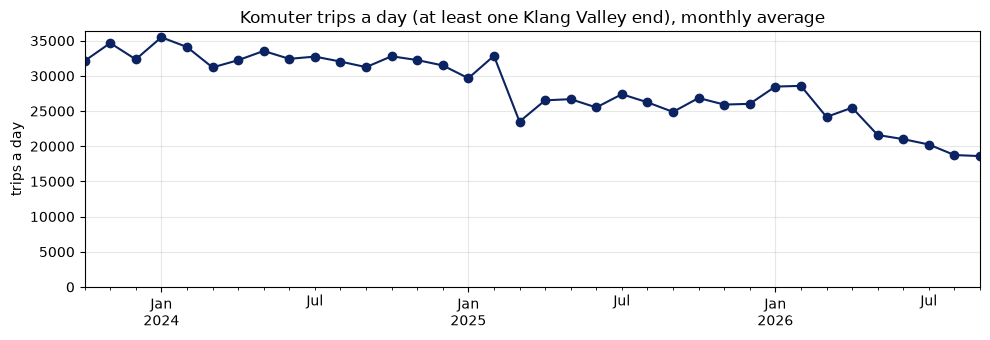

Largest month-to-month changes:
date
2025-03-01    -28.5%
2026-03-01    -15.5%
2026-05-01    -15.2%
2025-04-01    +12.9%
2025-02-01    +10.7%


In [6]:
daily = kv.groupby("date")["ridership"].sum()
monthly = daily.resample("MS").mean()

# VISUAL: monthly average trips a day
fig, ax = plt.subplots(figsize=(10, 3.5))
monthly.plot(ax=ax, marker="o", color="#0C2363")
ax.set_title("Komuter trips a day (at least one Klang Valley end), monthly average")
ax.set_ylabel("trips a day"); ax.set_xlabel(""); ax.set_ylim(0, None); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Largest month-to-month changes: a sudden step suggests a recording change
step = monthly.pct_change().dropna()
print("Largest month-to-month changes:")
print(step.reindex(step.abs().sort_values(ascending=False).index).head(5).map("{:+.1%}".format).to_string())

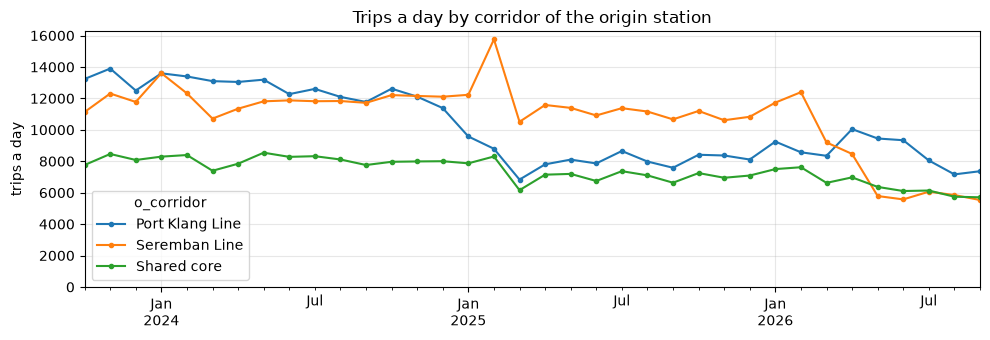

June to August 2024 against June to August 2026 (weekday and weekend counts are per day of that kind):
                        2024 a day  2026 a day change
All trips                  32400.0     19992.0   -38%
Within Klang Valley        23149.0     13874.0   -40%
One end outside             9251.0      6119.0   -34%
Weekday peak hours         23834.0     16905.0   -29%
Weekday off-peak hours     11393.0      6226.0   -45%
Weekends                   25594.0     12024.0   -53%
From Port Klang Line       12323.0      8170.0   -34%
From Seremban Line         11841.0      5829.0   -51%
From Shared core            8236.0      5993.0   -27%


In [7]:
# By corridor of the origin station
corr = stations.set_index("station")["corridor"]
kv["o_corridor"] = kv["origin"].map(corr)
by_corr = kv.groupby([pd.Grouper(key="date", freq="MS"), "o_corridor"])["ridership"].sum().unstack()
by_corr = by_corr.div(kv.groupby(pd.Grouper(key="date", freq="MS"))["date"].nunique(), axis=0)

# VISUAL: monthly trips a day by corridor of the origin station
fig, ax = plt.subplots(figsize=(10, 3.5))
by_corr.plot(ax=ax, marker=".")
ax.set_title("Trips a day by corridor of the origin station")
ax.set_ylabel("trips a day"); ax.set_xlabel(""); ax.set_ylim(0, None); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# By trip type and by peak or off-peak hours: similar falls everywhere suggest a recording change
def season(df, year):
    lo, hi = f"{year}-{SEASON[0]}", f"{year}-{SEASON[1]}"
    return df[(df["date"] >= lo) & (df["date"] <= hi)]

def per_day(df):
    return df["ridership"].sum() / df["date"].nunique()

a, b = season(kv, COMPARE_FROM), season(kv, COMPARE_TO)
peak = lambda d: d["hour"].between(*AM_PEAK) | d["hour"].between(*PM_PEAK)
weekday = lambda d: d["date"].dt.dayofweek < 5
rows = {
    "All trips": (a, b),
    "Within Klang Valley": (a[a.trip_type == "Within Klang Valley"], b[b.trip_type == "Within Klang Valley"]),
    "One end outside": (a[a.trip_type == "One end outside"], b[b.trip_type == "One end outside"]),
    "Weekday peak hours": (a[weekday(a) & peak(a)], b[weekday(b) & peak(b)]),
    "Weekday off-peak hours": (a[weekday(a) & ~peak(a)], b[weekday(b) & ~peak(b)]),
    "Weekends": (a[~weekday(a)], b[~weekday(b)]),
}
for c in by_corr.columns:
    rows[f"From {c}"] = (a[a.o_corridor == c], b[b.o_corridor == c])
tab = pd.DataFrame({k: [per_day(x), per_day(y)] for k, (x, y) in rows.items()}, index=[f"{COMPARE_FROM} a day", f"{COMPARE_TO} a day"]).T
tab["change"] = tab.iloc[:, 1] / tab.iloc[:, 0] - 1
print(f"June to August {COMPARE_FROM} against June to August {COMPARE_TO} (weekday and weekend counts are per day of that kind):")
print(tab.round(0).astype({"change": float}).assign(change=tab["change"].map("{:+.0%}".format)).to_string())

In [8]:
# By station: does every station fall by a similar share?
def station_entries(df):
    return df.groupby("origin")["ridership"].sum() / df["date"].nunique()

sa, sb = station_entries(a), station_entries(b)
chg = pd.DataFrame({f"{COMPARE_FROM}": sa, f"{COMPARE_TO}": sb}).fillna(0)
chg = chg[chg.max(axis=1) >= MIN_DAILY]
chg["change"] = chg[f"{COMPARE_TO}"] / chg[f"{COMPARE_FROM}"] - 1
chg.loc[chg[f"{COMPARE_FROM}"] < 1, "change"] = float("nan")   # no service in the earlier year: "new"
chg = chg.join(stations.set_index("station")[["corridor", "region"]]).sort_values("change")
print(f"Entries a day by station, June to August {COMPARE_FROM} against {COMPARE_TO} "
      f"(stations with at least {MIN_DAILY} a day in either year):")
print(chg.round({f"{COMPARE_FROM}": 0, f"{COMPARE_TO}": 0})
         .assign(change=chg["change"].map(lambda v: "new" if pd.isna(v) else f"{v:+.0%}")).to_string())
print(f"\nMedian station change: {chg['change'].median():+.0%}; "
      f"spread (middle half): {chg['change'].quantile(0.25):+.0%} to {chg['change'].quantile(0.75):+.0%}")

# Station pairs in use: if fewer pairs record trips, small flows may have stopped being counted
pairs = kv.groupby("date").apply(lambda d: d[["origin", "destination"]].drop_duplicates().shape[0])
print("\nStation pairs with at least one trip a day (monthly average):")
print(pairs.resample("QS").mean().round(0).astype(int).to_string())

Entries a day by station, June to August 2024 against 2026 (stations with at least 100 a day in either year):
                           2024    2026 change         corridor        region
origin                                                                       
Padang Jawa               546.0   122.0   -78%  Port Klang Line  Klang Valley
Bandar Tasek Selatan     1412.0   370.0   -74%    Seremban Line  Klang Valley
Pelabuhan Klang Selatan   266.0    77.0   -71%  Port Klang Line  Klang Valley
Klang                    1032.0   313.0   -70%  Port Klang Line  Klang Valley
Seremban                 1309.0   398.0   -70%    Seremban Line    Outer belt
Nilai                     642.0   199.0   -69%    Seremban Line    Outer belt
Serdang                   586.0   182.0   -69%    Seremban Line  Klang Valley
Subang Jaya              1550.0   486.0   -69%  Port Klang Line  Klang Valley
Batu Tiga                 339.0   107.0   -69%  Port Klang Line  Klang Valley
Setia Jaya                686.0 

## 6. A first look at the hours

The share of weekday and weekend entries in each hour, for June to August of `COMPARE_TO` (the same season as the main map). Step 3 of Version 6 will go further; this is only a check that the hourly pattern looks like commuting.

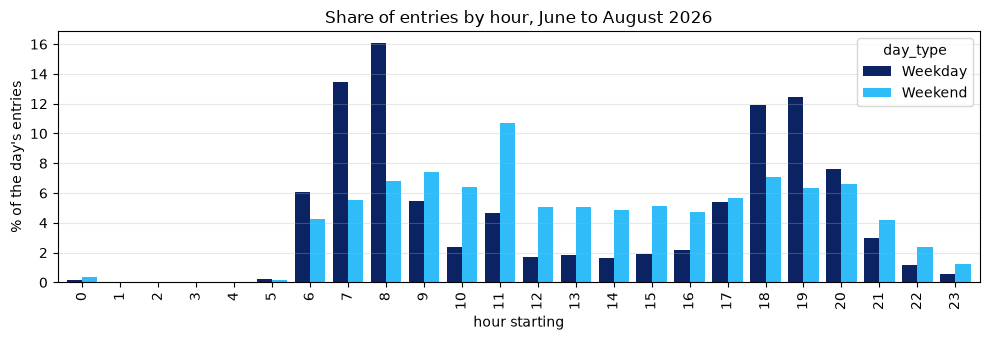

Weekday entries in the two peak windows (06:00 to 09:59 and 16:00 to 19:59): 73%


In [9]:
s = season(kv, COMPARE_TO).copy()
s["day_type"] = s["date"].dt.dayofweek.map(lambda d: "Weekday" if d < 5 else "Weekend")
hourly = s.groupby(["hour", "day_type"])["ridership"].sum().unstack()
hourly = hourly / hourly.sum() * 100

# VISUAL: share of entries by hour
fig, ax = plt.subplots(figsize=(10, 3.5))
hourly.plot(ax=ax, kind="bar", width=0.8, color=["#0C2363", "#30BCF8"])
ax.set_title(f"Share of entries by hour, June to August {COMPARE_TO}")
ax.set_ylabel("% of the day's entries"); ax.set_xlabel("hour starting"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

wd = hourly["Weekday"]
in_peaks = wd[wd.index.isin(range(AM_PEAK[0], AM_PEAK[1] + 1)) | wd.index.isin(range(PM_PEAK[0], PM_PEAK[1] + 1))].sum()
print(f"Weekday entries in the two peak windows ({AM_PEAK[0]:02d}:00 to {AM_PEAK[1]:02d}:59 and "
      f"{PM_PEAK[0]:02d}:00 to {PM_PEAK[1]:02d}:59): {in_peaks:.0f}%")

## 7. Save the outputs

- `komuter_od_hourly.parquet`: the clean trips (at least one Klang Valley end, from `START_DATE`), one row per date, hour, origin and destination.
- `komuter_stations.csv`: each station with its provisional region, district and corridor.
- `komuter_metadata.json`: what was done, for the README and the next notebooks.

In [10]:
out = kv[["date", "hour", "origin", "destination", "ridership", "trip_type"]].reset_index(drop=True)
out.to_parquet(PROCESSED / "komuter_od_hourly.parquet", index=False)
stations.to_csv(PROCESSED / "komuter_stations.csv", index=False)

meta = {
    "source": "Hourly Origin-Destination Ridership: Komuter, data.gov.my (CC BY 4.0)",
    "created": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "first_date": str(out["date"].min().date()),
    "last_date": str(out["date"].max().date()),
    "rows": int(len(out)),
    "trips": int(out["ridership"].sum()),
    "dropped_stations": DROP_STATIONS,
    "rule": "trips with at least one end in the Klang Valley (KL, Putrajaya, Petaling, Gombak, Ulu Langat, Klang, Sepang)",
    "station_regions": "provisional, by name; to be checked against KTMB GTFS coordinates",
    "compare_season": f"June to August {COMPARE_FROM} against {COMPARE_TO}",
    "change_all_trips": round(float(tab.loc["All trips", "change"]), 4),
}
(PROCESSED / "komuter_metadata.json").write_text(json.dumps(meta, indent=2))
for f in ["komuter_od_hourly.parquet", "komuter_stations.csv", "komuter_metadata.json"]:
    print(f"{f}: {(PROCESSED / f).stat().st_size / 1e6:.1f} MB")

komuter_od_hourly.parquet: 14.5 MB
komuter_stations.csv: 0.0 MB
komuter_metadata.json: 0.0 MB


___
**END**